In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs, make_circles
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

import warnings
warnings.filterwarnings("ignore")

#ładujemy dane

df_account = pd.read_csv('C:\\Users\\micha\\OneDrive\\Pulpit\\laba\projekt zaliczeniowy\\archive\\account.csv', sep = ';', quotechar='"')
df_loan = pd.read_csv('C:\\Users\\micha\\OneDrive\\Pulpit\\laba\projekt zaliczeniowy\\archive\\loan.csv', sep = ';', quotechar='"')
df_client = pd.read_csv('C:\\Users\\micha\\OneDrive\\Pulpit\\laba\projekt zaliczeniowy\\archive\\client.csv', sep = ';', quotechar='"')
df_card = pd.read_csv('C:\\Users\\micha\\OneDrive\\Pulpit\\laba\projekt zaliczeniowy\\archive\\card.csv', sep = ';', quotechar='"')
df_disp = pd.read_csv('C:\\Users\\micha\\OneDrive\\Pulpit\\laba\projekt zaliczeniowy\\archive\\disp.csv', sep = ';', quotechar='"')
df_district = pd.read_csv('C:\\Users\\micha\\OneDrive\\Pulpit\\laba\projekt zaliczeniowy\\archive\\district.csv', sep = ';', quotechar='"')
df_order = pd.read_csv('C:\\Users\\micha\\OneDrive\\Pulpit\\laba\projekt zaliczeniowy\\archive\\order.csv', sep = ';', quotechar='"')
df_trans = pd.read_csv('C:\\Users\\micha\\OneDrive\\Pulpit\\laba\projekt zaliczeniowy\\archive\\trans.csv', sep = ';', quotechar='"')


# Konwertuje zapis dat

df_trans["date"] = pd.to_datetime(df_trans["date"], format="%y%m%d")
df_loan["date"] = pd.to_datetime(df_loan["date"], format="%y%m%d")


# 1. wczytanie danych district (gdyż tam trzeba sie pobawić aby uzyskać dobrze stope bezrobocia)
df_district= pd.read_csv(
    'C:\\Users\\micha\\OneDrive\\Pulpit\\laba\projekt zaliczeniowy\\archive\\district.csv',
    sep=';',
    na_values='?'   # zamienia ? → NaN
)

# 2. zmiana nazw kolumn
df_district.columns = [
    'district_id', 'district_name', 'region', 'population',
    'muni_lt_499', 'muni_500_1999', 'muni_2000_9999', 'muni_gt_10000',
    'cities', 'urban_ratio', 'avg_salary',
    'unemp_1995', 'unemp_1996',
    'entrepreneurs_per_1000',
    'crimes_1995', 'crimes_1996'
]

# 3. konwersja typów (na wszelki wypadek)
numeric_cols = [
    'population', 'muni_lt_499', 'muni_500_1999', 'muni_2000_9999',
    'muni_gt_10000', 'cities', 'urban_ratio', 'avg_salary',
    'unemp_1995', 'unemp_1996',
    'entrepreneurs_per_1000', 'crimes_1995', 'crimes_1996'
]

df_district[numeric_cols] = df_district[numeric_cols].apply(pd.to_numeric, errors='coerce')

# 4. obsługa braków danych
df_district = df_district.fillna(df_district.median(numeric_only=True))

# 5. dodanie zmiennej: zmiana bezrobocia
df_district['change_unemp'] = df_district['unemp_1996'] - df_district['unemp_1995']



df_trans.head(3)




,trans_id,account_id,date,type,operation,amount,balance,k_symbol,bank,account
0,695247,2378,1993-01-01,PRIJEM,VKLAD,700.0,700.0,NaN,NaN,NaN
1,171812,576,1993-01-01,PRIJEM,VKLAD,900.0,900.0,NaN,NaN,NaN
2,207264,704,1993-01-01,PRIJEM,VKLAD,1000.0,1000.0,NaN,NaN,NaN


In [9]:
df_trans["operation"].unique

<bound method Series.unique of 0          VKLAD
1          VKLAD
2          VKLAD
3          VKLAD
4          VKLAD
           ...  
1056315      NaN
1056316      NaN
1056317      NaN
1056318      NaN
1056319      NaN
Name: operation, Length: 1056320, dtype: object>

In [10]:
splaty = df_trans[df_trans["k_symbol"] == "UVER"] #licze ile jest spłat


liczba_splat = (
    splaty.groupby("account_id")
    .size()
    .reset_index(name="liczba_splat")
)


df_model = df_loan.merge(liczba_splat, on="account_id", how="left")

df_model["liczba_splat"] = df_model["liczba_splat"].fillna(0)

# dodaje do df_loan info o tym ile zostało spłaconych rat
df_loan = df_loan.merge(liczba_splat, on="account_id", how="left")
df_loan["liczba_splat"] = df_loan["liczba_splat"].fillna(0)


df_loan[["account_id", "liczba_splat"]].head(10)
df_loan["procent_splaty"] = df_loan["liczba_splat"] / df_loan["duration"] #dodaje procent splaconych pozyczek (ile zostało rat splaconych/przez ilosc rat do spłąty)

In [11]:
#łączymy kolumny w jedną tabele
df = df_account\
    .merge(df_disp, on='account_id', how='left')\
    .merge(df_client, on='client_id', how='left')\
    .merge(df_loan, on='account_id', how='left')\
    .merge(df_card, on='disp_id', how='left')\
    .merge(df_district, left_on='district_id_x', right_on='district_id', how='left')

print(df.shape)
print(df.head())
#_id_x -> z account
#id_y -> z client


(5369, 37)
   account_id  district_id_x         frequency  date_x  disp_id  client_id  \
0         576             55  POPLATEK MESICNE  930101      692        692   
1         576             55  POPLATEK MESICNE  930101      693        693   
2        3818             74  POPLATEK MESICNE  930101     4601       4601   
3        3818             74  POPLATEK MESICNE  930101     4602       4602   
4         704             55  POPLATEK MESICNE  930101      844        844   

      type_x  birth_number  district_id_y  loan_id  ... muni_gt_10000  cities  \
0      OWNER        365111             74      NaN  ...             0       9   
1  DISPONENT        350317             74      NaN  ...             0       9   
2      OWNER        350402              1      NaN  ...             1       1   
3  DISPONENT        345404              1      NaN  ...             1       1   
4      OWNER        450114             22      NaN  ...             0       9   

   urban_ratio  avg_salary unemp_

In [12]:
trans_count = df_trans.groupby('account_id').size().reset_index(name='liczba_transakcji') #liczę liczbe transakcji na konto
df = df.merge(trans_count, on='account_id', how='left') #dodaję liczbe wykonanych transakcji do głównej tabeli
print(trans_count)

      account_id  liczba_transakcji
0              1                239
1              2                478
2              3                117
3              4                186
4              5                 84
...          ...                ...
4495       11333                368
4496       11349                304
4497       11359                378
4498       11362                344
4499       11382                253

[4500 rows x 2 columns]


In [13]:
#usuwam te wiersze które nie mają statusu pożyczki uzupełnionej
df = df[df['status'].notna()]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 55 to 5351
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   account_id              827 non-null    int64         
 1   district_id_x           827 non-null    int64         
 2   frequency               827 non-null    object        
 3   date_x                  827 non-null    int64         
 4   disp_id                 827 non-null    int64         
 5   client_id               827 non-null    int64         
 6   type_x                  827 non-null    object        
 7   birth_number            827 non-null    int64         
 8   district_id_y           827 non-null    int64         
 9   loan_id                 827 non-null    float64       
 10  date_y                  827 non-null    datetime64[ns]
 11  amount                  827 non-null    float64       
 12  duration                827 non-null    float64      

In [15]:
#dodajemy nową kolumne niespłacone pożyczki
#1-niespłacenie pożyczki,0 spłącenie pożyczki
df['niespłacone_pozyczki'] = df['status'].isin(['B', 'D']).astype(int) 

# dodajemy wiek kijenta
df['wiek_kijenta'] =2026-(1900+df['birth_number'] // 10000)

#dodajemy info o płci kijenta
df['plec'] = (
    (df['birth_number'] % 10000 // 100) > 50
).map({True: 'Kobieta', False: 'Mezczyzna'})
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 55 to 5351
Data columns (total 41 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   account_id              827 non-null    int64         
 1   district_id_x           827 non-null    int64         
 2   frequency               827 non-null    object        
 3   date_x                  827 non-null    int64         
 4   disp_id                 827 non-null    int64         
 5   client_id               827 non-null    int64         
 6   type_x                  827 non-null    object        
 7   birth_number            827 non-null    int64         
 8   district_id_y           827 non-null    int64         
 9   loan_id                 827 non-null    float64       
 10  date_y                  827 non-null    datetime64[ns]
 11  amount                  827 non-null    float64       
 12  duration                827 non-null    float64      

In [16]:
#usuwam  kolumny nie potrzebne do analizy

df = df.drop(columns=['account_id', 'disp_id', 'client_id','district_id_y','loan_id','frequency'])


In [17]:
print(df.info())
print(df.head(5))

<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 55 to 5351
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   district_id_x           827 non-null    int64         
 1   date_x                  827 non-null    int64         
 2   type_x                  827 non-null    object        
 3   birth_number            827 non-null    int64         
 4   date_y                  827 non-null    datetime64[ns]
 5   amount                  827 non-null    float64       
 6   duration                827 non-null    float64       
 7   payments                827 non-null    float64       
 8   status                  827 non-null    object        
 9   liczba_splat            827 non-null    float64       
 10  procent_splaty          827 non-null    float64       
 11  card_id                 170 non-null    float64       
 12  type_y                  170 non-null    object       

In [18]:
#tworze nowa tabele z danymi ktore bede sprawdzał w analizie
df_new = df[['niespłacone_pozyczki','liczba_splat','procent_splaty','wiek_kijenta','plec','district_name', 'region', 'unemp_1995', 'unemp_1996','crimes_1995','crimes_1996','payments','amount','avg_salary','liczba_transakcji','duration']]

In [19]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 827 entries, 55 to 5351
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   niespłacone_pozyczki  827 non-null    int64  
 1   liczba_splat          827 non-null    float64
 2   procent_splaty        827 non-null    float64
 3   wiek_kijenta          827 non-null    int64  
 4   plec                  827 non-null    object 
 5   district_name         827 non-null    object 
 6   region                827 non-null    object 
 7   unemp_1995            827 non-null    float64
 8   unemp_1996            827 non-null    float64
 9   crimes_1995           827 non-null    float64
 10  crimes_1996           827 non-null    int64  
 11  payments              827 non-null    float64
 12  amount                827 non-null    float64
 13  avg_salary            827 non-null    int64  
 14  liczba_transakcji     827 non-null    int64  
 15  duration              827 

brak brakujących wartości

In [20]:
print(df_new.describe()) #mam pogląd do podstawowych danych statystycznych każdej kolumny (suma,średnia arytmetyczna, odchylenie standardowe,max,min)

       niespłacone_pozyczki  liczba_splat  procent_splaty  wiek_kijenta  \
count            827.000000    827.000000      827.000000    827.000000   
mean               0.091898     20.082225        0.636845     68.103990   
std                0.289057     12.574254        0.331272     12.961718   
min                0.000000      1.000000        0.016667     41.000000   
25%                0.000000     12.000000        0.333333     57.500000   
50%                0.000000     17.000000        0.666667     68.000000   
75%                0.000000     26.000000        1.000000     79.000000   
max                1.000000     60.000000        1.083333     92.000000   

       unemp_1995  unemp_1996   crimes_1995   crimes_1996     payments  \
count  827.000000  827.000000    827.000000    827.000000   827.000000   
mean     2.860562    3.499528  14896.850060  16603.539299  4231.251511   
std      1.841233    2.127614  27191.239371  31585.083216  2238.757849   
min      0.290000    0.43000

In [21]:
df_new.corr(numeric_only=True) #sprawdzam korelacje pomiedzy danymi

,niespłacone_pozyczki,liczba_splat,procent_splaty,wiek_kijenta,unemp_1995,unemp_1996,crimes_1995,crimes_1996,payments,amount,avg_salary,liczba_transakcji,duration
niespłacone_pozyczki,1.000000,0.005579,-0.040882,0.005524,0.017850,0.020701,-0.025780,-0.027032,0.156414,0.147798,-0.030072,0.039469,0.027352
liczba_splat,0.005579,1.000000,0.501718,-0.063622,-0.007081,-0.016999,0.029625,0.029712,-0.089757,0.167340,0.058045,0.602665,0.389444
procent_splaty,-0.040882,0.501718,1.000000,-0.002215,0.033856,0.026772,0.061353,0.060575,-0.018559,-0.375223,0.102452,0.676579,-0.529838
wiek_kijenta,0.005524,-0.063622,-0.002215,1.000000,0.026813,0.020651,-0.038755,-0.039440,-0.019918,-0.076046,-0.050993,-0.058742,-0.058210
unemp_1995,0.017850,-0.007081,0.033856,0.026813,1.000000,0.974581,-0.504320,-0.508843,-0.014660,-0.066569,-0.392100,-0.020302,-0.045714
unemp_1996,0.020701,-0.016999,0.026772,0.020651,0.974581,1.000000,-0.525838,-0.530821,0.002876,-0.054840,-0.427078,-0.029993,-0.046160
crimes_1995,-0.025780,0.029625,0.061353,-0.038755,-0.504320,-0.525838,1.000000,0.999657,0.040331,0.032873,0.908455,0.063088,-0.043240
crimes_1996,-0.027032,0.029712,0.060575,-0.039440,-0.508843,-0.530821,0.999657,1.000000,0.038926,0.032050,0.903596,0.064050,-0.042485
payments,0.156414,-0.089757,-0.018559,-0.019918,-0.014660,0.002876,0.040331,0.038926,1.000000,0.683020,0.025837,-0.013365,-0.042414
amount,0.147798,0.167340,-0.375223,-0.076046,-0.066569,-0.054840,0.032873,0.032050,0.683020,1.000000,0.002625,-0.084241,0.615840


Z tabeli możemy odczytać iż korelacje z niespłaconymi pożyczkami nie są zbyt wysokie. 


Najwiekszą dodatnią korelacje z niespłąconymi pożyczkami mają kolumny (czyli wpływają pozytywnie na ryzyko niespłącenia kredytu):
payments=0,156
amount=0,147
liczba transakcji = 0,039


Najwiekszą ujemną korelacje z niespłąconymi pożyczkami mają kolumny (czyli wpływają ujemnie na ryzyko niespłącenia kredytu):
procent_splaty = -0.040
avg_salary = -0.030
crimes_1995 = -0.027


In [ ]:
Histogramy i wykresy pudełkowe

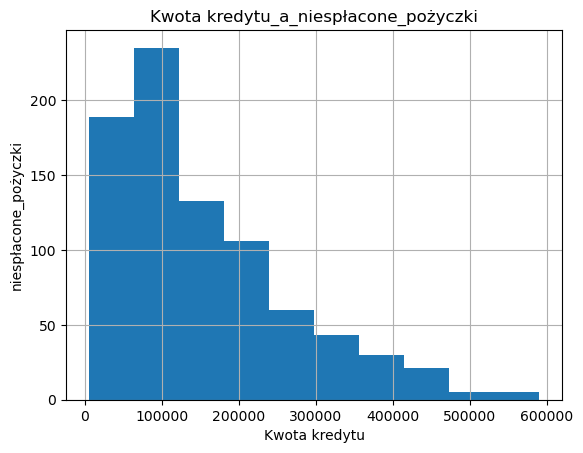

In [29]:
df_new["amount"].hist()
plt.xlabel("Kwota kredytu")
plt.ylabel("niespłacone_pożyczki")
plt.title("Kwota kredytu_a_niespłacone_pożyczki")
plt.show()

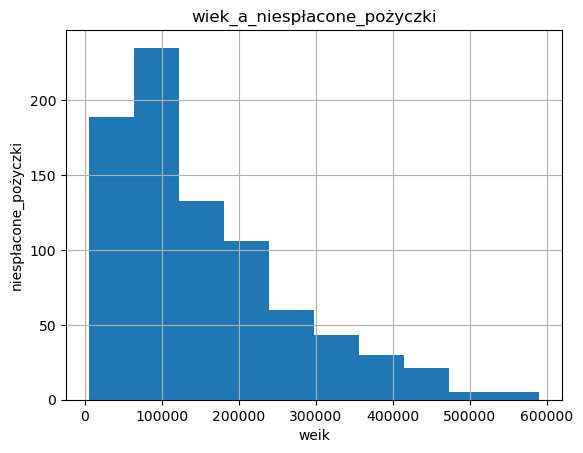

In [30]:
df_new["amount"].hist()
plt.xlabel("wiek")
plt.ylabel("niespłacone_pożyczki")
plt.title("wiek_a_niespłacone_pożyczki")
plt.show()

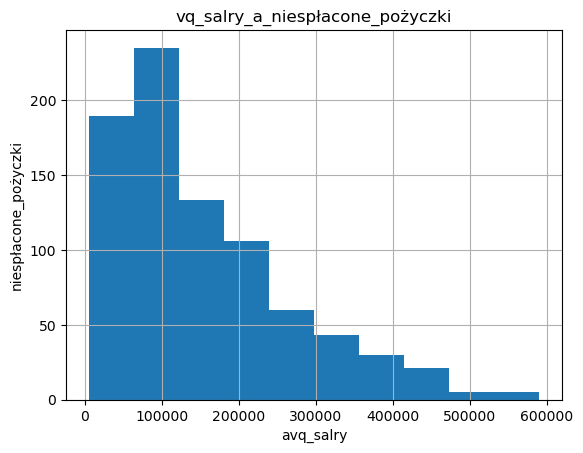

In [31]:
df_new["amount"].hist()
plt.xlabel("avq_salry")
plt.ylabel("niespłacone_pożyczki")
plt.title("vq_salry_a_niespłacone_pożyczki")
plt.show()

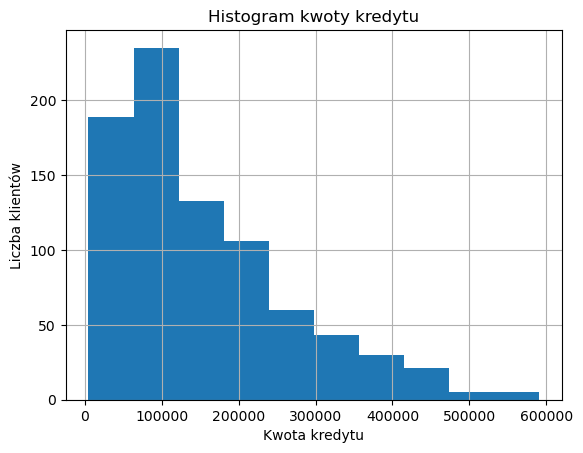

In [22]:

df_new["amount"].hist()
plt.xlabel("Kwota kredytu")
plt.ylabel("Liczba klientów")
plt.title("Histogram kwoty kredytu")
plt.show()


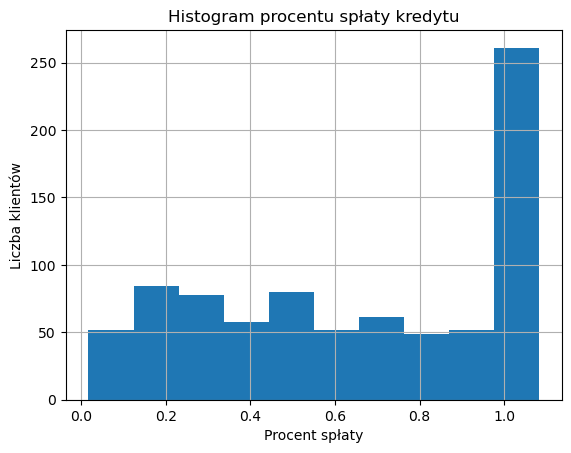

In [23]:

df_new["procent_splaty"].hist()
plt.xlabel("Procent spłaty")
plt.ylabel("Liczba klientów")
plt.title("Histogram procentu spłaty kredytu")
plt.show()


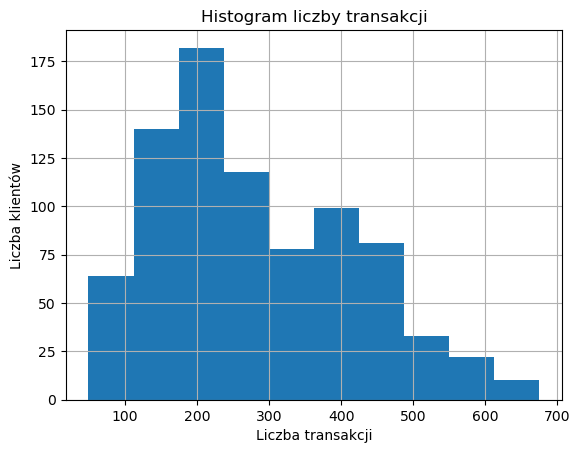

In [24]:

df_new["liczba_transakcji"].hist()
plt.xlabel("Liczba transakcji")
plt.ylabel("Liczba klientów")
plt.title("Histogram liczby transakcji")
plt.show()


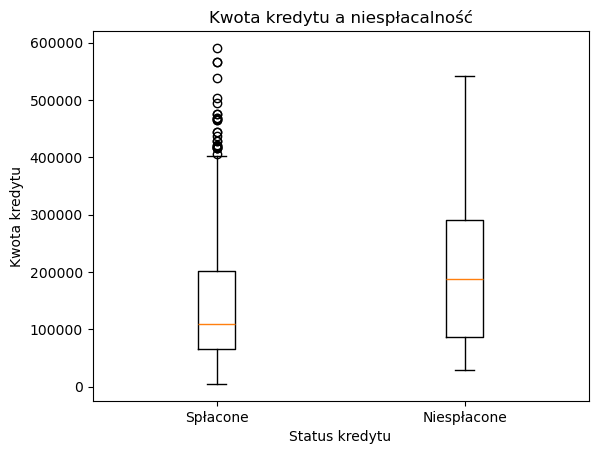

In [86]:

plt.boxplot([
    df_new[df_new["niespłacone_pozyczki"] == 0]["amount"],
    df_new[df_new["niespłacone_pozyczki"] == 1]["amount"]
])

plt.xticks([1, 2], ["Spłacone", "Niespłacone"])
plt.xlabel("Status kredytu")
plt.ylabel("Kwota kredytu")
plt.title("Kwota kredytu a niespłacalność")
plt.show()


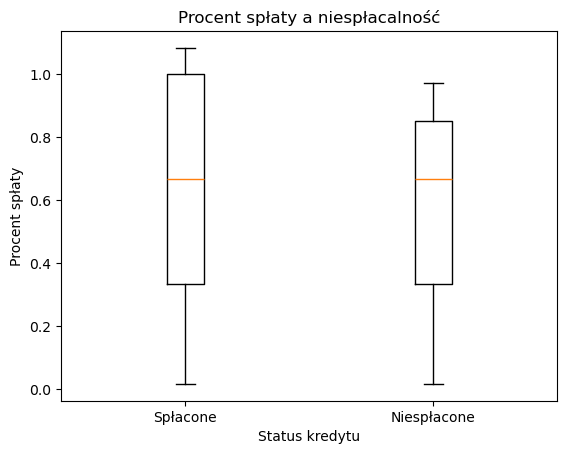

In [87]:

plt.boxplot([
    df_new[df_new["niespłacone_pozyczki"] == 0]["procent_splaty"],
    df_new[df_new["niespłacone_pozyczki"] == 1]["procent_splaty"]
])

plt.xticks([1, 2], ["Spłacone", "Niespłacone"])
plt.xlabel("Status kredytu")
plt.ylabel("Procent spłaty")
plt.title("Procent spłaty a niespłacalność")
plt.show()


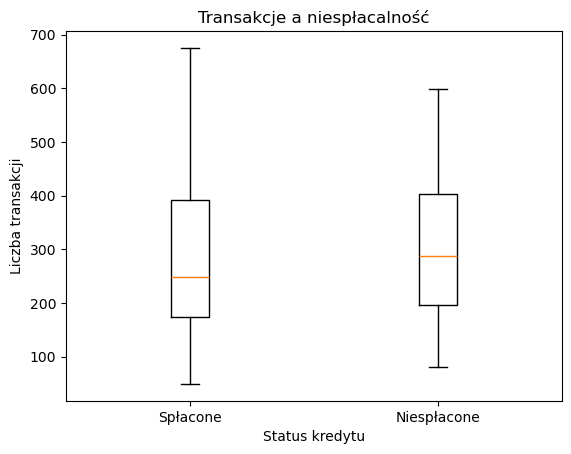

In [88]:

plt.boxplot([
    df_new[df_new["niespłacone_pozyczki"] == 0]["liczba_transakcji"],
    df_new[df_new["niespłacone_pozyczki"] == 1]["liczba_transakcji"]
])

plt.xticks([1, 2], ["Spłacone", "Niespłacone"])
plt.xlabel("Status kredytu")
plt.ylabel("Liczba transakcji")
plt.title("Transakcje a niespłacalność")
plt.show()


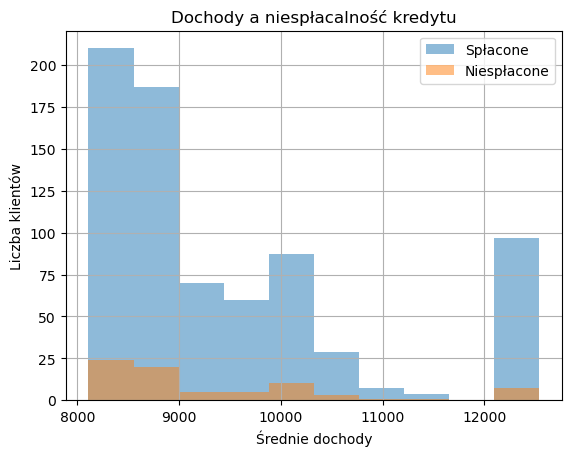

In [90]:

df_new[df_new["niespłacone_pozyczki"] == 0]["avg_salary"].hist(alpha=0.5)
df_new[df_new["niespłacone_pozyczki"] == 1]["avg_salary"].hist(alpha=0.5)

plt.xlabel("Średnie dochody")
plt.ylabel("Liczba klientów")
plt.title("Dochody a niespłacalność kredytu")
plt.legend(["Spłacone", "Niespłacone"])
plt.show()


3. Budowa modelu predykcyjnego 
● Przygotuj dane do modelowania: 
● Zakoduj zmienne kategoryczne. 
● Znormalizuj lub standaryzuj dane. 
● Podziel zbiór danych na zestaw treningowy i testowy. 
● Zbuduj model klasyfikacyjny przewidujący, czy pożyczka nie zostanie spłacona: 
● Wypróbuj różne algorytmy, np. regresję logistyczną, drzewa decyzyjne, lasy losowe, 
XGBoost. 
● Porównaj wyniki modeli na podstawie metryk takich jak dokładność, precyzja, 
recall, F1-score (szczególnie istotny będzie *recall dla klasy "niespłacona pożyczka"*). 
● Zwizualizuj krzywe ROC i macierz pomyłek. 

In [ ]:
Modelowanie

In [ ]:
Logistic Regression

Accuracy: 0.6385542168674698
Precision: 0.13114754098360656
Recall: 0.5333333333333333
F1: 0.21052631578947367
ROC AUC: 0.6176600441501103
niespłacone_pozyczki
0    751
1     76
Name: count, dtype: int64


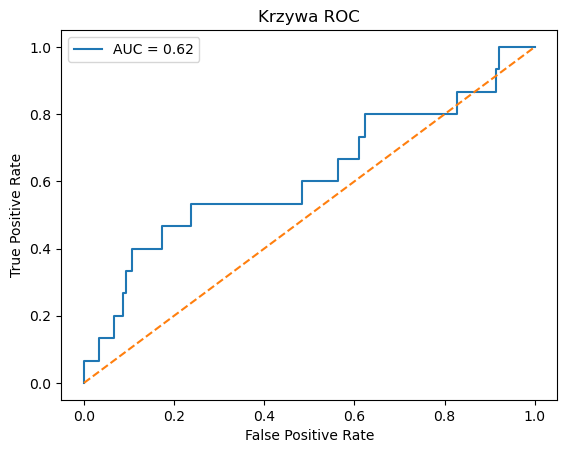

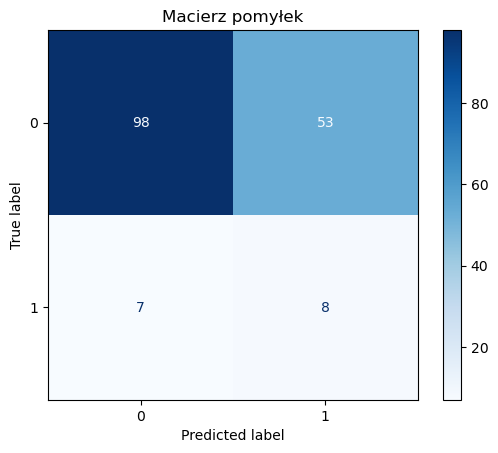

In [122]:

# TARGET
y = df_new['niespłacone_pozyczki']

# FEATURES
X = df_new.drop(columns=['niespłacone_pozyczki'])

# zamiana kategorii na liczby
X = pd.get_dummies(X)

# split (bo brak czasu)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)


# predykcja
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ocena
from sklearn.metrics import *

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print(y.value_counts())
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().tail(10)


#krzywa ROC
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # linia losowa
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Krzywa ROC")
plt.legend()
plt.show()

#MAcierz pomyłek

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Macierz pomyłek")
plt.show()



Accuracy (ilość przewidywań prawidłowych): 0.6385542168674698

Precision(precyzja "spośród tych, których model uznał za „1” — ilu naprawdę nimi jest"): 0.13114754098360656

Recall(czułość "ile 1 model wykrył"): 0.5333333333333333

F1( balans między precision i recall): 0.21052631578947367

ROC AUC (jak dobrze model rozróżnia klasy (0 vs 1): 0.6176600441501103

Model działa średnio dobrze (ROC AUC ok. 0.62). Udało się sprawić, że wykrywa ponad połowę osób, które nie spłacają kredytu (recall ok. 53%), co jest plusem.
Problem jest taki, że często się myli i oznacza jako „ryzykownych” ludzi, którzy tak naprawdę spłacają kredyt (niska precyzja ok. 13%).

Krzywa ROC -Model trochę rozróżnia klientów spłacających i niespłacających, ale nie robi tego zbyt dobrze.

Macierz pomyłek

98 osób → dobrze przewidział jako spłacających 
53 osoby → błędnie uznał za niespłacających 
7 osób → nie wykrył problemu 
8 osób → dobrze wykrył niespłacenie 

2.Drzewa Decyzyjne

Accuracy: 0.8493975903614458
Precision: 0.1875
Recall: 0.2
F1: 0.1935483870967742
ROC AUC: 0.5569536423841059
niespłacone_pozyczki
0    751
1     76
Name: count, dtype: int64
procent_splaty                0.267423
liczba_transakcji             0.125482
payments                      0.113271
wiek_kijenta                  0.071004
unemp_1995                    0.052981
region_south Bohemia          0.050850
amount                        0.045547
avg_salary                    0.035318
district_name_Brno - mesto    0.032172
duration                      0.025228
dtype: float64
   real  pred  prob
0     0     0   0.0
1     0     0   0.0
2     0     0   0.0
3     0     0   0.0
4     0     0   0.0


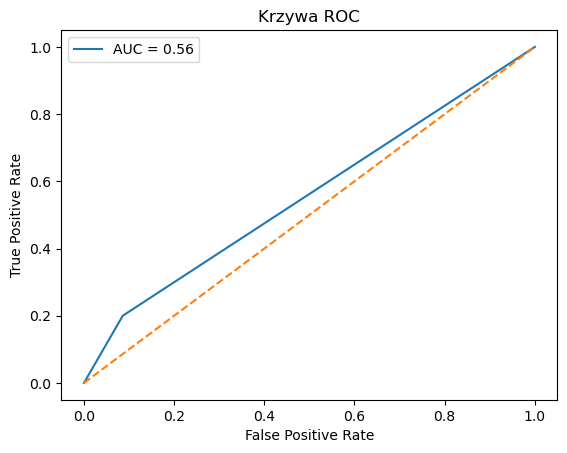

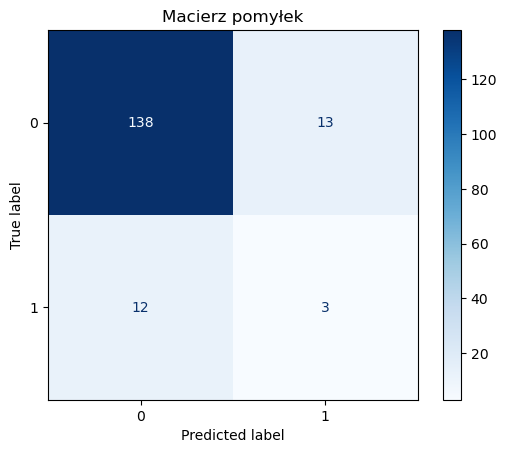

In [126]:

# TARGET
y = df_new['niespłacone_pozyczki']

# FEATURES
X = df_new.drop(columns=['niespłacone_pozyczki'])

# zamiana kategorii na liczby
import pandas as pd
X = pd.get_dummies(X)

# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# MODEL – Decision Tree
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# predykcja
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ocena
from sklearn.metrics import *

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print(y.value_counts())

# ważność cech
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False).head(10))

# porównanie wyników
results = pd.DataFrame({
    'real': y_test.values,
    'pred': y_pred,
    'prob': y_prob
})

print(results.head(5))

# ROC curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Krzywa ROC")
plt.legend()
plt.show()

# macierz pomyłek
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Macierz pomyłek")
plt.show()


Model działa słabo (ROC AUC ok. 0.56) – jest tylko trochę lepszy niż losowe zgadywanie.
Accuracy jest dość wysokie (~85%), ale wynika to głównie z tego, że większość klientów spłaca kredyt
(751 spłacających vs tylko 76 niespłacających → duża nierównowaga klas).


Model wykrywa tylko 20% osób, które naprawdę nie spłacają kredytu (recall = 0.2) → bardzo mało
gdy już oznaczy kogoś jako „ryzykownego”, to ma rację tylko w ~19% przypadków (precision = 0.19)


model często przegapia osoby niespłacające i jednocześnie popełnia błędy wskazując „ryzykownych”, którzy faktycznie spłacają

📉 Krzywa ROC
ROC AUC ≈ 0.56
model prawie nie rozróżnia dobrze klientów spłacających i niespłacających
Krzywa jest blisko przekątnej → podobna do zgadywania losowego.

🔢 Macierz pomyłek
Z obrazu:

138 osób → dobrze przewidział jako spłacających (TN)
13 osób → błędnie uznał za niespłacających (FP)
12 osób → nie wykrył problemu (FN)
3 osoby → dobrze wykrył niespłacenie (TP)

👉 Wniosek:

model praktycznie nie łapie klasy 1 (niespłacających)
tylko 3 poprawne trafienia na 15 rzeczywistych przypadków


Największy wpływ mają:
procent_splaty (0.267) → zdecydowanie najważniejsza cecha
liczba_transakcji, payments
wiek_klienta
unemp_1995
region (region_south Bohemia)
amount, avg_salary


Model ma wysoką accuracy, ale jest myląca (imbalans klas)
bardzo słabo wykrywa niespłacających (niski recall)
średnio trafia w swoje przewidywania (niska precision)
ROC AUC pokazuje, że model prawie nie uczy się sensownego rozróżnienia klas



3. Las losowy

Accuracy: 0.9096385542168675
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC AUC: 0.7485651214128035
niespłacone_pozyczki
0    751
1     76
Name: count, dtype: int64
   real  pred  prob
0     0     0  0.02
1     0     0  0.11
2     0     0  0.02
3     0     0  0.15
4     0     0  0.10


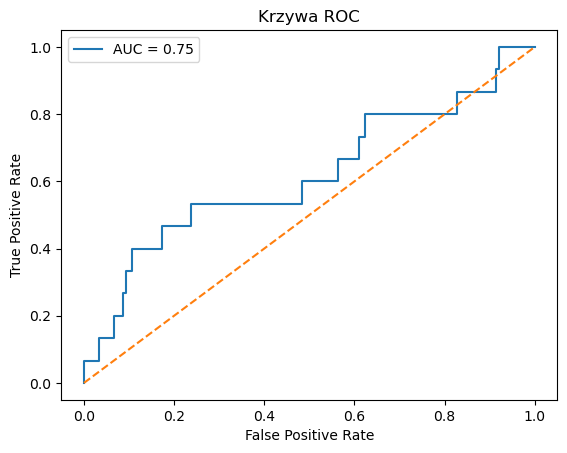

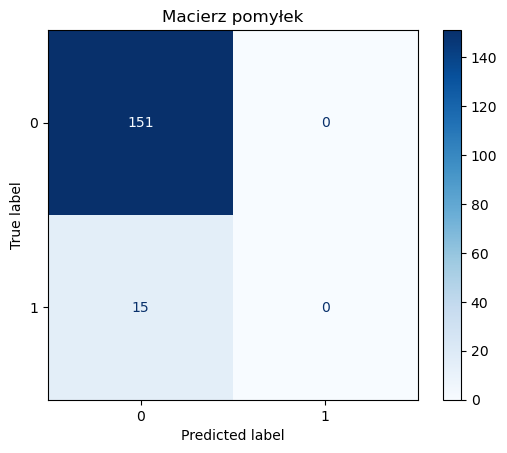

In [124]:

# TARGET
y = df_new['niespłacone_pozyczki']

# FEATURES
X = df_new.drop(columns=['niespłacone_pozyczki'])

# zamiana kategorii na liczby
X = pd.get_dummies(X)

# split (bo brak czasu)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# model
from sklearn.linear_model import LogisticRegression



model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)



# predykcja
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ocena
from sklearn.metrics import *

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print(y.value_counts())


importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().tail(10)



results = pd.DataFrame({
    'real': y_test.values,
    'pred': y_pred,
    'prob': y_prob
})

print(results.head(5)) #kolumny prawda/przewidywanie/pewność

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # linia losowa
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Krzywa ROC")
plt.legend()
plt.show()

#MAcierz pomyłek

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Macierz pomyłek")
plt.show()

📊 Metryki modelu
Accuracy (ilość przewidywań prawidłowych):
0.9096385542168675
Precision (precyzja – „spośród tych, których model uznał za 1 — ilu naprawdę nimi jest”):
0.0
Recall (czułość – „ile 1 model wykrył”):
0.0
F1 (balans między precision i recall):
0.0
ROC AUC (jak dobrze model rozróżnia klasy 0 vs 1):
0.7485651214128035

model w ogóle nie przewiduje klasy 1 (niespłacających)
dlatego:

recall = 0 (nie wykrył ANI JEDNEGO przypadku)
precision = 0 (bo nie było żadnych predykcji „1”)
F1 = 0

Czyli model działa jak:
„wszyscy spłacą kredyt”

4. Analiza

Najlepszy model jest Logistic Regression, gdyż ma najwyższy współczynik recall. Dodatkow ROC =0,62 zatem model jest nieznacznie lepiej rozroznia klasy od losowego zgadywania. Model częściej oznacza klientów jako ryzykownych mimo poprawnej spłaty kredytu (wysoki poziom false positives).

Natomiast ten model uzyskał najwiekszy Recall z wszystkich modeli, który jest na poziomie około 53%. Oznacza to, że model wykrywa ponad połowę klientów, którzy faktycznie nie spłacą kredytu.


Z perspektywy banku może to być akceptowalne, ponieważ zmniejsza ryzyko udzielenia kredytu klientowi, który faktycznie nie spłaci zobowiązania.


Największy wpływ na spłate kredytu mają czyniki:
-historia spłat (procent_splaty)
- obciążenie finansowe (payments, amount)
- aktywność finansowa (liczba_transakcji)
- sytuacja ekonomiczna (dochody, bezrobocie, region)


Problemem w danych jest iż mam dużo osób spłącających kredyt a małą ilośc danych tych którzy nie spłącają.

Najważniejsze cechy wpływające na przewidywanie niespłacenia pożyczki to:
procent spłaty kredytu (procent_splaty),
wysokość raty i kwoty kredytu (payments, amount),
liczba transakcji,
średnie wynagrodzenie klienta,
poziom bezrobocia w regionie,
wiek klienta.

Wyniki sugerują, że największy wpływ na problemy ze spłatą mają:

wysokie obciążenie finansowe klienta,
słaba historia spłat,
gorsza sytuacja ekonomiczna regionu,
niższa aktywność finansowa.



Model można ulepszyć zarówno poprzez inżynierię cech, jak i dostrojenie hiperparametrów modeli.

Inżynieria cech (feature engineering)

W projekcie wykorzystano podstawowe cechy klientów i pożyczek, jednak można stworzyć dodatkowe zmienne lepiej opisujące ryzyko kredytowe klienta.

Warto było by dodać:
-amount / duration
-payments / salary
-liczba_transakcji / miesiąc





W praktyce bankowej taki model może wspierać proces oceny ryzyka kredytowego. Może być wykorzystywany do:
automatycznej oceny klientów,
wspomagania decyzji kredytowych,
wykrywania klientów wysokiego ryzyka,
ograniczania strat wynikających z niespłaconych pożyczek.
